In [9]:
from fastai.vision.all import *

In [6]:
torch.cuda.is_available()

True

In [7]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3080 Ti'

In [1]:
sampling_frequency = 100 # Hz

In [2]:
import pandas as pd
import numpy as np

from scipy.signal import ShortTimeFFT
from scipy.signal.windows import hamming

def create_spectrograms(df : pd.DataFrame, fault_category : str, SECONDS : int=2, nperseg=None, train_seconds=None, val_seconds=None, test_seconds=None, mode='train'):
    """
    Generates and returns spectrograms for specified time segments.

    Parameters:
    dataDict (dict): Dict containing fault category data.
    fault_category (str): Category to process.
    SECONDS (int): Length of each spectrogram segment in seconds.
    nperseg (int): FFT window size.
    train_seconds (list of tuples): List of (start, end) in seconds for training.            all_labels.append(fault_category)
    val_seconds (list of tuples): List of (start, end) in seconds for validation.
    mode (str): 'train' or 'val' - determines which segments to use.

    Returns:
    spectrograms, labels
    """
    all_spectrograms = []
    all_labels = []
    segments = []

    treshold = 2

    peak_time = df[df["sensor_1"] == df["sensor_1"].max()]["time_sec"].max()

    start_time = peak_time - treshold
    end_time = peak_time + treshold
    
    segments.append((start_time, end_time))

    for start_sec, end_sec in segments:
        num_segments = int((end_sec - start_sec) // SECONDS)

        for i in range(num_segments):
            spec_8ch = get_8_channel_spectrogram(
                df[(df["time_sec"] >= start_time) & (df["time_sec"] <= end_time)], nperseg)

            all_spectrograms += spec_8ch

            # One fault category for each sensor (the fault is the same)
            all_labels.append(fault_category)
            all_labels.append(fault_category)
            all_labels.append(fault_category)
            all_labels.append(fault_category)


            print(f"Generated {i+1} spectrograms - label: {fault_category}")

    return all_spectrograms, all_labels

def get_8_channel_spectrogram(data, sampling_frequency = 200, nperseg = 32):

    all_spectrograms = []

    # Slice to first 5 seconds if desired
    
    for column in data:
        if column.startswith("sensor_1") or column.startswith("sensor_2") or column.startswith("sensor_3") or column.startswith("sensor_4"): # This can be used to filter out specific columns
            
            col = data[column]
            w = hamming(nperseg) # Hamming window
            Sft = ShortTimeFFT(w, hop=int(nperseg*0.05), fs=sampling_frequency, scale_to='psd')
            Sxx = Sft.spectrogram(col.values)  # calculate absolute square of STFT
            all_spectrograms.append(Sxx)

    return all_spectrograms

In [3]:
from pathlib import Path

import pandas as pd
import os

def get_data(dir: Path, fault_category: str):
    directory = os.listdir(str(dir))
    
    data = []
    fault_labels = []

    for file in directory:
        if (("Session" in file and "_rel_time" in file)):
            df = pd.DataFrame(pd.read_csv(str(dir/file)))
            spec, labels = create_spectrograms(df, fault_category, SECONDS=4, nperseg=256, train_seconds=[(df["time_sec"].min(), df["time_sec"].max())])
            data += spec
            fault_labels += labels
    
    return data, fault_labels

In [4]:
all_spectograms = []
all_labels = []

In [5]:
hard_falls, hard = get_data(Path('.data/train/hardFall'), "Hard Fall")
all_spectograms += hard_falls
all_labels += hard

Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label

In [6]:
controlled_falls, controlled = get_data(Path('.data/train/controlledFall'), 'Controlled Fall')
slip_trip_falls, slip_trip = get_data(Path('.data/train/Slip/Trip'), 'SlipTrip')

all_spectograms += controlled_falls
all_labels += controlled

all_spectograms += slip_trip_falls
all_labels += slip_trip

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall


In [10]:
def show_spectogram(img: TensorImage, title : str = "Final Tensor Image"):
    img_array = img.numpy()

# Convert from (C, H, W) to (H, W, C) for matplotlib
    if img_array.shape[0] == 3:  # RGB
        img_plot = np.transpose(img_array, (1, 2, 0))
    else:  # Grayscale
        img_plot = img_array[0]

    plt.figure(figsize=(5, 5))
    plt.imshow(img_plot, aspect='auto', origin='lower', cmap='viridis')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Frequency')
    plt.colorbar(label='Amplitude')
    plt.show()
    plt.close()

In [11]:
len(all_labels)

576

In [12]:
len(all_spectograms)

576

In [13]:
def split():
    valid_spec = []
    valid_labels = []

    size : int = 60
    
    for i in range(0, size):
        ran_num = random.randint(0, len(all_labels))

        del all_spectograms [ran_num]
        del all_labels [ran_num]

        valid_spec.append(all_spectograms[ran_num])
        valid_labels.append(all_labels[ran_num])
    
    return valid_spec, valid_labels

In [14]:
valid_spec, valid_labels = split()

In [25]:
for i in range(len(all_labels)):
    if all_labels[i] == "SlipTrip":
        print(i)
        break

349


In [16]:
hard_falls[0].shape

(17, 831)

In [17]:
len(all_spectograms)

516

In [18]:
print(f'Initial shape of a spectrogram: ', all_spectograms[0].shape)

ch, freq_bins = all_spectograms[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx)
print(f'Final shape: {final_shape}')
print(f'Input Type: {type(all_spectograms[0])}')


Initial shape of a spectrogram:  (17, 831)
Final shape: (17, 233)
Input Type: <class 'numpy.ndarray'>


In [19]:
# constants you can tweak once
FLOOR_DB   = -1.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [20]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

def create_tensor_image(i : int):
        """
        Convert spectrogram to TensorImage format
        """

        # Normalization - turn spectrogram into dB scale
        arr_db = 10 * np.log10(all_spectograms[i])
        #arr_db = np.clip(arr_db, FLOOR_DB, 0)

        # Scale to [0, 1]
        arr_01 = (arr_db - FLOOR_DB) / (-FLOOR_DB)

        # If spectrogram is multi-channel, convert to grayscale first
        if len(arr_db.shape) == 3:
                arr_01 = np.mean(arr_db, axis=-1)  # average across channels
        
        arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
        
        # Apply colormap to convert grayscale to color
        # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
        colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
        arr_colored = colormap(arr_01)  # This returns RGBA (H, W, 4)
        
        # Convert RGBA to RGB (drop alpha channel)
        arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
        
        # Convert to PyTorch tensor with correct channel ordering
        t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
        
        # Resize image
        t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
        
        return TensorImage(t_resized.squeeze(0))  # (3, H, W)

/tmp/ipykernel_50366/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'


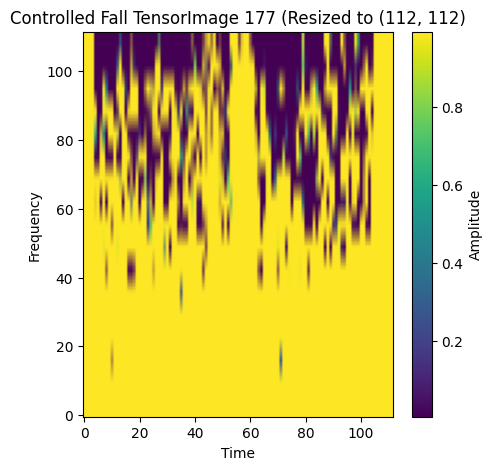

In [21]:
show_spectogram(create_tensor_image(177), title=f'Controlled Fall TensorImage {177} (Resized to {TARGET_HW}')

/tmp/ipykernel_50366/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'


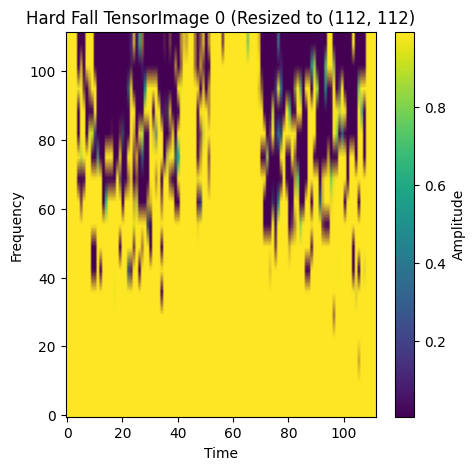

In [23]:
show_spectogram(create_tensor_image(0), title=f'Hard Fall TensorImage {0} (Resized to {TARGET_HW}')

/tmp/ipykernel_50366/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'


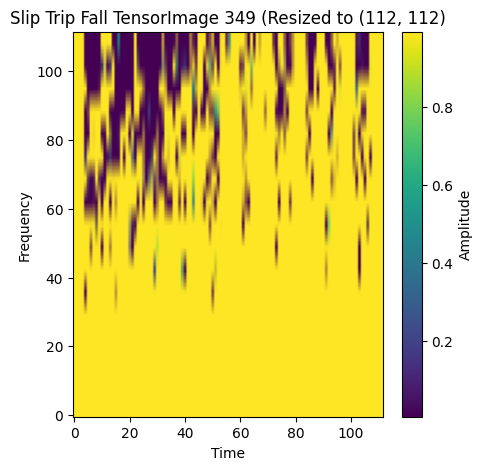

In [26]:
show_spectogram(create_tensor_image(349), title=f'Slip Trip Fall TensorImage {349} (Resized to {TARGET_HW}')


In [23]:
all_labels[5]

'Hard Fall'

/tmp/ipykernel_50366/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'


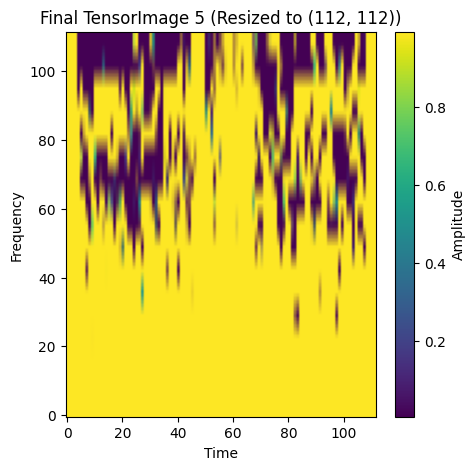

In [27]:
import matplotlib.pyplot as plt

tensor_img = create_tensor_image(5)
    
# Convert back to numpy for plotting
# TensorImage format is (C, H, W)
img_array = tensor_img.numpy()

# Convert from (C, H, W) to (H, W, C) for matplotlib
if img_array.shape[0] == 3:  # RGB
    img_plot = np.transpose(img_array, (1, 2, 0))
else:  # Grayscale
    img_plot = img_array[0]

plt.figure(figsize=(5, 5))
plt.imshow(img_plot, aspect='auto', origin='lower', cmap='viridis')
plt.title(f'Final TensorImage {5} (Resized to {TARGET_HW})')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.colorbar(label='Amplitude')
plt.show()

In [25]:
def get_x(i):
    arr = all_spectograms[i]                 # expected (C, F, T)

    # To tensor; keep size unless RESIZE_HW is set
    t = torch.from_numpy(arr).float().unsqueeze(0)  # (1, C, F, T)
    if TARGET_HW is not None:
        t = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)

    return TensorImage(t.squeeze(0))      # (C, F, T) or (C, H, W) if resized

def get_y(i):
    return all_labels[i]


In [26]:
from pathlib import Path

def build_items(path: Path):
    items = []  # list of (spec_path, label)
    for folder in sorted(os.listdir(path/"train")):
        folder_path = path/"train"/folder
        if not folder_path.is_dir(): 
            continue
        lbl_path = folder_path/"labels.npy"
        if not lbl_path.exists():
            continue

        labels = np.load(lbl_path)
        spec_files = sorted(
            f for f in os.listdir(folder_path)
            if f.endswith(".npy") and f != "labels.npy"
        )

        n = min(len(labels), len(spec_files))
        for f, lab in zip(spec_files[:n], labels[:n]):
            items.append((folder_path/f, lab))
    return items


In [27]:
def time_series_splitter(items):
    n_train = len(all_spectograms)
    return list(range(n_train)), list(range(n_train, len(items)))

In [28]:
block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=create_tensor_image,
    get_y=get_y,
)

In [29]:
len(all_spectograms)

516

In [30]:
len(all_labels)

516

In [31]:
items = list(range(len(all_spectograms)))   # or `range(N)`
dls = block.dataloaders(items, bs=16)

/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'


/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'


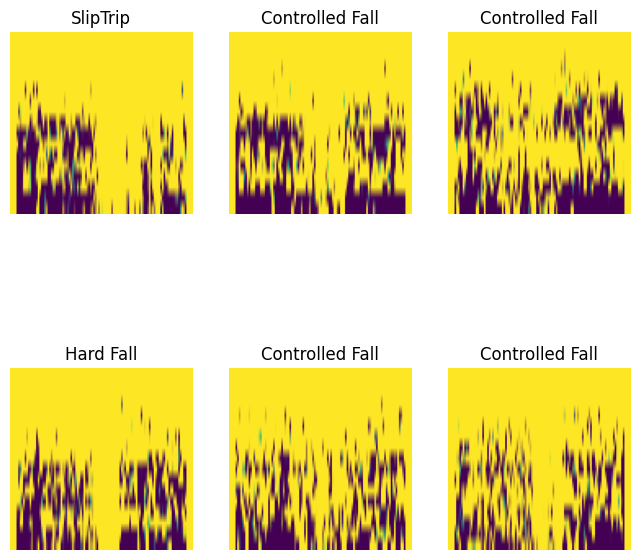

In [32]:
dls.show_batch(max_n=6, figsize=(8,8))

In [33]:
model = nn.Sequential(
    
    nn.Conv2d(3, 8, kernel_size=4, stride=2),     # (8, 55, 55)
    nn.BatchNorm2d(8),
    nn.ReLU(),
            
    nn.Conv2d(8, 16, kernel_size=3, stride=2),     # (16, 27, 27)
    nn.BatchNorm2d(16),
    nn.ReLU(),
        
    nn.Conv2d(16, 32, kernel_size=3, stride=2),    # (32, 13, 13)
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32, 64, kernel_size=3, stride=2),    # (64, 6, 6)
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64*6*6, 14)
)

In [34]:
learner = Learner(dls, model=model, loss_func=CrossEntropyLossFlat(), metrics=accuracy)

In [35]:
learner.summary()

/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'


Sequential (Input shape: 16 x 3 x 112 x 112)
Layer (type)         Output Shape         Param #    Trainable 
                     16 x 8 x 55 x 55    
Conv2d                                    392        True      
BatchNorm2d                               16         True      
ReLU                                                           
____________________________________________________________________________
                     16 x 16 x 27 x 27   
Conv2d                                    1168       True      
BatchNorm2d                               32         True      
ReLU                                                           
____________________________________________________________________________
                     16 x 32 x 13 x 13   
Conv2d                                    4640       True      
BatchNorm2d                               64         True      
ReLU                                                           
___________________________________

/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ip

SuggestedLRs(valley=0.0003981071640737355, slide=0.02754228748381138, steep=0.001737800776027143)

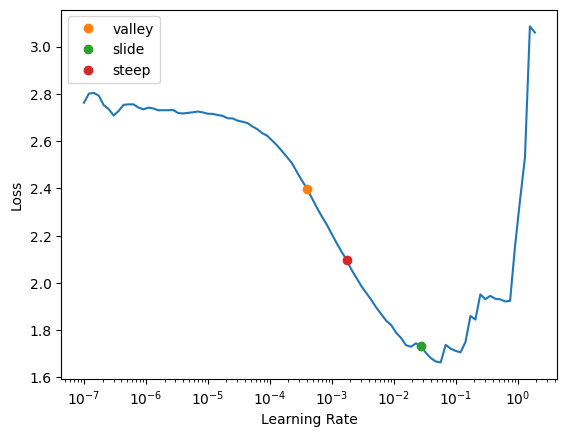

In [36]:
learner.lr_find(suggest_funcs=(valley,slide,steep))

In [37]:
learner.fit_one_cycle(20, 1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,2.009662,1.903187,0.281553,00:00
1,1.444660,1.086730,0.398058,00:00
2,1.104545,0.808740,0.757282,00:00
3,0.824322,0.825481,0.621359,00:00
4,0.577870,0.611333,0.757282,00:00
5,0.387452,0.557758,0.815534,00:00
6,0.255567,0.547022,0.805825,00:00
7,0.166765,0.530726,0.834951,00:00
8,0.109719,0.508828,0.825243,00:00
9,0.073332,0.506784,0.844660,00:00


/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ip

/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ip

/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ip

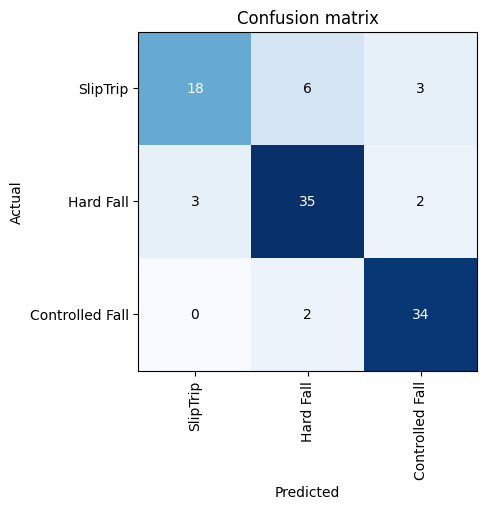

In [38]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [39]:
inter_plot.most_confused()

/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ip

[('SlipTrip', 'Hard Fall', np.int64(6)),
 ('SlipTrip', 'Controlled Fall', np.int64(3)),
 ('Hard Fall', 'SlipTrip', np.int64(3)),
 ('Hard Fall', 'Controlled Fall', np.int64(2)),
 ('Controlled Fall', 'Hard Fall', np.int64(2))]

/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'


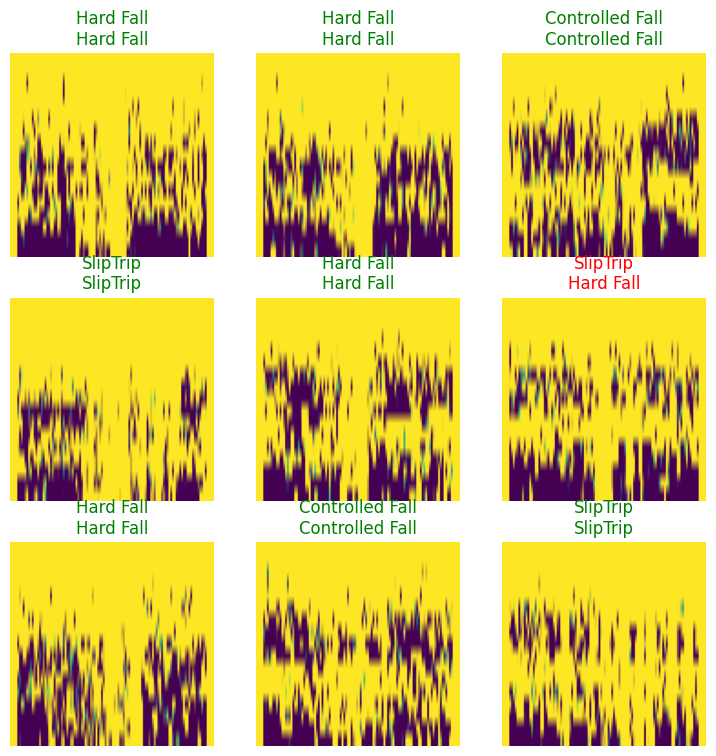

In [40]:
learner.show_results()

In [41]:
def get_x_test(i):
    arr_db = 10 * np.log10(valid_spec[i])
    arr_db = np.clip(arr_db, FLOOR_DB, 0)

    # Scale to [0, 1]
    arr_01 = (arr_db - FLOOR_DB) / (-FLOOR_DB)

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr_01.shape) == 3:
            arr_01 = np.mean(arr_01, axis=-1)  # average across channels
    
    arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr_01)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [46]:
learner.validate()

/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_4882/2084464766.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ip

(#2) [0.49706345796585083,0.844660222530365]

## Accuracy

This is the relationship between True labes, and all predicted labels. This determens how accurate the model is to predict the true lables. 

$$Accuracy = \frac{TP + TN}{TP + TN + FN + FP} $$

## Precision

The amount of True (or False) labels the model did find belonging to the positive class. The number of True Positives divided by True Positives plus False Positives.  

$$ Precision = \frac{TP}{TP + FP} $$

In [ ]:
def get_y_pred(learner: Learner, val_set : list):
    y_pred = []
    y_test = []
    
    for i in range(len(val_set)):
        y_pred.append(learner.predict(get_x_test(i))[0])
        y_test.append(get_y_test(i))
    return y_pred, y_test 
    


In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [71]:
y_pred, y_test = get_y_pred(learner, valid_spec)

In [74]:
accuracy_score(y_test, y_pred)

0.9333333333333333

In [78]:
precision_score(y_test, y_pred, average='macro')

0.9419191919191919

In [80]:
recall_score(y_test, y_pred, average="macro")

0.9253034547152194

In [82]:
f1_score(y_test, y_pred, average="macro")

0.9299933679071942

In [45]:
dir = Path('./models')

learner.path = dir

learner.export('classifier.pkl')